# Customer Segmentation — RFM + K-Means

An **unsupervised** machine-learning walkthrough: group an online retailer's
customers into behavioural segments from their purchase history alone, so
marketing can treat each group differently.

This notebook mirrors `segmentation_analysis.py`, with the reasoning shown
step by step. Dataset: the public UCI *Online Retail* set (a UK gift-ware store,
Dec 2010 – Dec 2011).

**Author:** Muhammad Nasiruddin

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams["figure.figsize"] = (6, 4)
RANDOM_STATE = 42
GREEN, BLUE = "#2a9d8f", "#264653"
PALETTE = ["#2a9d8f", "#e76f51", "#264653", "#e9c46a"]

## 2. Load & clean

The raw file is one row per line-item. We drop cancelled orders (invoices
starting with `C`), rows with no `CustomerID`, and non-sales rows (zero/negative
quantity or price), then compute a `TotalPrice` per line.

In [2]:
df = pd.read_excel("data/Online Retail.xlsx")
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df.dropna(subset=["CustomerID"])
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["CustomerID"] = df["CustomerID"].astype(int)
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(f"Transactions: {len(df):,}")
print(f"Customers:    {df['CustomerID'].nunique():,}")
print(f"Revenue:      £{df['TotalPrice'].sum():,.0f}")
df.head()

Transactions: 397,884
Customers:    4,338
Revenue:      £8,911,408


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Build the RFM table

We collapse the transaction log into **one row per customer** with three
behavioural features:

- **Recency** — days since their last purchase (lower is better)
- **Frequency** — number of distinct orders
- **Monetary** — total spend

In [3]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
)
rfm.describe().round(1)

,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0
mean,92.5,4.3,2054.3
std,100.0,7.7,8989.2
min,1.0,1.0,3.8
25%,18.0,1.0,307.4
50%,51.0,2.0,674.5
75%,142.0,5.0,1661.7
max,374.0,209.0,280206.0


## 4. Rule-based RFM scoring (the traditional method)

Before any ML, the classic approach scores every customer **1–5** on each
dimension using quintiles. A combined score near 15 = best customer, near 3 =
lost. We keep this as a transparent baseline to compare against K-Means.

In [4]:
score = pd.DataFrame(index=rfm.index)
score["R"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1]).astype(int)
score["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
score["M"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5]).astype(int)
score["RFM_Score"] = score[["R","F","M"]].sum(axis=1)
print("Best customers (>=13):", (score["RFM_Score"]>=13).sum())
print("Lost customers (<=5): ", (score["RFM_Score"]<=5).sum())
score.head()

Best customers (>=13): 934
Lost customers (<=5):  883


,R,F,M,RFM_Score
CustomerID,,,,
12346,1,1,5,7
12347,5,5,5,15
12348,2,4,4,10
12349,4,1,4,9
12350,1,1,2,4


## 5. Prepare features for K-Means

RFM is heavily right-skewed (a few customers spend 1000× the median), so we
**log-transform** then **standardise** — otherwise K-Means, a distance method,
is dominated by outliers.

In [5]:
rfm_log = np.log1p(rfm[["Recency","Frequency","Monetary"]])
X = StandardScaler().fit_transform(rfm_log)
X[:3]

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ]])

## 6. Choose k — elbow + silhouette

We scan k = 2..8 and look at inertia (the "elbow") and the silhouette score.
The elbow softens around **k = 4**, which also gives four segments that map onto
distinct marketing actions — so we choose k = 4.

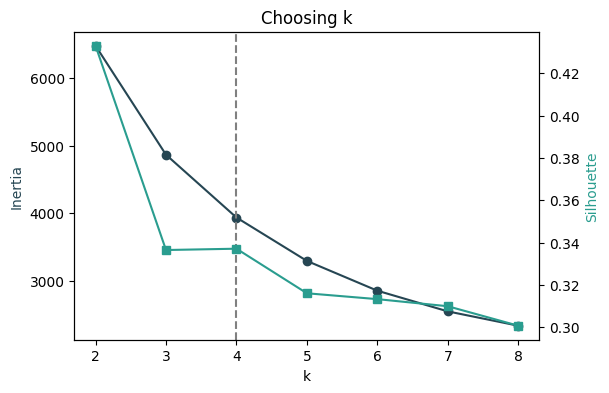

In [6]:
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, ax1 = plt.subplots()
ax1.plot(list(ks), inertia, "o-", color=BLUE); ax1.set_ylabel("Inertia", color=BLUE)
ax1.axvline(4, ls="--", color="grey"); ax1.set_xlabel("k")
ax2 = ax1.twinx(); ax2.plot(list(ks), sil, "s-", color=GREEN)
ax2.set_ylabel("Silhouette", color=GREEN); plt.title("Choosing k"); plt.show()

## 7. Cluster and check against a second algorithm

We fit K-Means at k = 4, then sanity-check with hierarchical clustering. K-Means
wins on silhouette and scales better, so we keep it.

In [7]:
K = 4
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X)
rfm["Cluster"] = km.labels_

agg = AgglomerativeClustering(n_clusters=K).fit(X)
print(f"K-Means silhouette:       {silhouette_score(X, km.labels_):.3f}")
print(f"Agglomerative silhouette: {silhouette_score(X, agg.labels_):.3f}")

K-Means silhouette:       0.337
Agglomerative silhouette: 0.242


## 8. Profile & name the segments

In [8]:
profile = rfm.groupby("Cluster").agg(
    Recency=("Recency","median"), Frequency=("Frequency","median"),
    Monetary=("Monetary","median"), Customers=("Recency","size"))

def name_row(r):
    if r["Monetary"] == profile["Monetary"].max(): return "Champions"
    if r["Recency"]  == profile["Recency"].max():  return "At-risk / Lapsing"
    if r["Recency"]  == profile["Recency"].min():  return "New / Promising"
    return "Loyal regulars"

profile["Segment"] = profile.apply(name_row, axis=1)
profile

,Recency,Frequency,Monetary,Customers,Segment
Cluster,,,,,
0,17.0,2.0,471.700,837,Loyal regulars
1,8.0,10.0,3733.870,716,Champions
2,56.0,4.0,1345.620,1173,Loyal regulars
3,177.0,1.0,298.255,1612,At-risk / Lapsing


## 9. Visualise the segments

**PCA projection** (see the clusters in 2-D) and a **snake plot** (each segment's
standardised RFM shape).

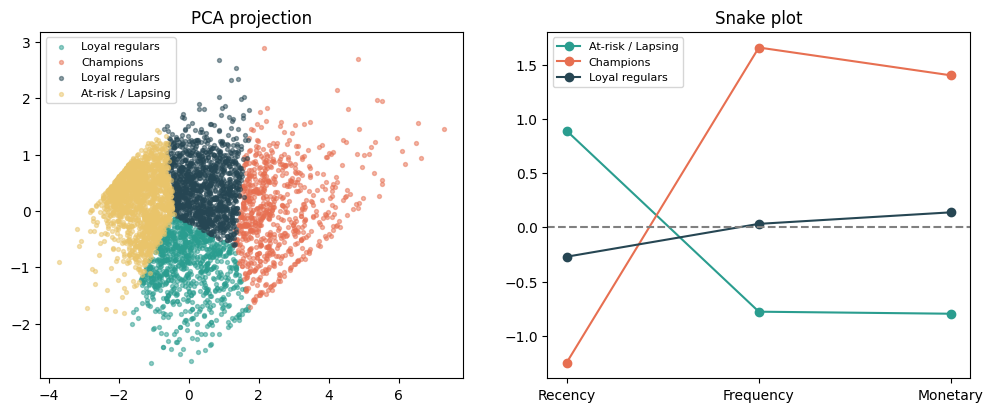

In [9]:
names = profile["Segment"].to_dict()
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for c in sorted(rfm["Cluster"].unique()):
    m = rfm["Cluster"].values == c
    axes[0].scatter(coords[m,0], coords[m,1], s=8, alpha=.5,
                    color=PALETTE[c], label=names[c])
axes[0].set_title("PCA projection"); axes[0].legend(fontsize=8)

sc = pd.DataFrame(X, columns=["Recency","Frequency","Monetary"], index=rfm.index)
sc["Seg"] = rfm["Cluster"].map(names).values
for i,(seg,row) in enumerate(sc.groupby("Seg")[["Recency","Frequency","Monetary"]].mean().iterrows()):
    axes[1].plot(["Recency","Frequency","Monetary"], row.values, "o-",
                 color=PALETTE[i], label=seg)
axes[1].axhline(0, ls="--", color="grey"); axes[1].set_title("Snake plot")
axes[1].legend(fontsize=8); plt.show()

## 10. Where the money is (Pareto)

Customer *count* and *revenue* are different stories — a small segment can carry
the business.

In [10]:
rev = rfm.groupby("Cluster")["Monetary"].sum()
share = (rev / rev.sum()).sort_values(ascending=False)
share.index = share.index.map(names)
(share * 100).round(1).to_frame("Revenue %")

,Revenue %
Cluster,
Champions,64.9
Loyal regulars,23.7
At-risk / Lapsing,6.2
Loyal regulars,5.2


## Takeaways

- **Champions** are a small segment but drive the majority of revenue — protect
  them first.
- The largest segment is **At-risk / Lapsing** — a capped win-back campaign fits.
- **New / Promising** customers are where a second-purchase nudge pays off.
- Two methods agree on the structure: rule-based RFM scoring and K-Means both
  surface the same high/low-value split — evidence the segments are real.